<a href="https://colab.research.google.com/github/hila-yogev/Final_Project_social-media-productivity/blob/main/Signal_Processing_Project_1_Hila_Yogev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Signal Processing - Project 1

# Part 1: Sampling Theorem: Nyquist frequency, Aliasing, Quantization

The experiment lasted 30 seconds, during which a stimulus inducing 2 Hz oscillations was applied from second 12 to second 30, the first 9 seconds are considered as baseline activity (we ignore seconds 9 - 12).  The data were sampled at 50 Hz.

Import the necessary  libraries, define constants and load data

In [ ]:
##### 1.0 - Import libraries and environment setup #####

import numpy as np
import pandas as pd
import gdown
import matplotlib.pyplot as plt
from scipy.signal import correlate


In [ ]:
##### 1.1 - Load Data and Define Experimental Constants #####

# Google Drive file IDs
file_id_neural = '1mv96N96ysK3g6hn0NttwMsuqMnD6FNYN'
file_id_spikes = '11Ud-K5sohcS42nTtZ2df4j2CjloW5qys'

# Construct direct download URLs
url_1 = f'https://drive.google.com/uc?id={file_id_neural}'
url_2 = f'https://drive.google.com/uc?id={file_id_spikes}'

# Download files
gdown.download(url_1, 'Neural_data.csv', quiet=False)
gdown.download(url_2, 'Spike_trains.csv', quiet=False)

# Load the data
df_Neural_data = pd.read_csv('Neural_data.csv')
df_spike_trains = pd.read_csv('Spike_trains.csv')

Downloading...
From: https://drive.google.com/uc?id=1mv96N96ysK3g6hn0NttwMsuqMnD6FNYN
To: /content/Neural_data.csv
100%|██████████| 26.0k/26.0k [00:00<00:00, 28.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=11Ud-K5sohcS42nTtZ2df4j2CjloW5qys
To: /content/Spike_trains.csv
100%|██████████| 30.2M/30.2M [00:00<00:00, 87.4MB/s]


In [ ]:
##### 1.1 - Signal Extraction and Time Vector Creation #####

# Print the column names and shape to verify the file structure
print(df_spike_trains.shape)
print(f"Data 1 Column names: {df_Neural_data.columns}")
print(f"Data 2 Column names: {df_spike_trains.columns}")

# --- Extract the neural signal ---
# Column 0 is the frame index, column 1 is the ΔF/F (%) signal from df1
signal = df_Neural_data.iloc[:, 1].to_numpy()

# Define constants
fs = 50          # Sampling frequency [Hz]
dt = 1 / fs      # Sampling time step [s]
duration = 30    # Recording duration [s]

# Create a time vector - time axis [s]
t = np.arange(len(signal)) * dt   # output - [0.00, 0.02, 0.04...]

# Verification prints
print(f"\nNeural Data Columns: {df_Neural_data.columns.tolist()}")
print(f"Number of samples: {len(signal)}")
print(f"Sampling time step: {dt} seconds")
print(f"Sampling frequency: {fs} Hz")
print(f"Duration according to data: {len(signal) / fs} seconds")

(500, 30001)
Data 1 Column names: Index(['Frame', 'ΔF/F (%)'], dtype='object')
Data 2 Column names: Index(['trial_neuron', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '29990', '29991', '29992', '29993', '29994', '29995', '29996', '29997',
       '29998', '29999'],
      dtype='object', length=30001)

Neural Data Columns: ['Frame', 'ΔF/F (%)']
Number of samples: 1500
Sampling time step: 0.02 seconds
Sampling frequency: 50 Hz
Duration according to data: 30.0 seconds


## 1.1 A - Divide signal into noise and stim, create plots


Divide the signal into different parts, let the noisy part be from the beginning to second 9 of the recording, and the stimulus part be from second 12 to the end of the recording. Plot the whole signal and each part (noise and stimulus) in a different figure.

In [ ]:
##### 1.1A - Signal Segmentation (Noise vs Stimulus) #####

# Create boolean masks for each part of the signal
# True - keep this sample
# False - ignore this sample
noise_mask = (t >= 0) & (t < 9)
stim_mask = (t >= 12) & (t < 30)

# Use the masks to extract the relevant time points (x) and signal values (y)
t_noise = t[noise_mask]
noise_signal = signal[noise_mask]
t_stim = t[stim_mask]
stim_signal = signal[stim_mask]

# Count samples and convert counts back to time to ensure accuracy
noise_samples = len(noise_signal)
noise_duration = len(noise_signal) / fs
stim_samples = len(stim_signal)
stim_duration = len(stim_signal) / fs

# Print information to verify that the segmentation is correct
print(f"Noise samples: {noise_samples}")
print(f"Noise duration: {noise_duration} seconds")

print(f"\nStimulus samples: {stim_samples}")
print(f"Stimulus duration: {stim_duration} seconds")

Noise samples: 450
Noise duration: 9.0 seconds

Stimulus samples: 900
Stimulus duration: 18.0 seconds


Figure 1: Full Signal


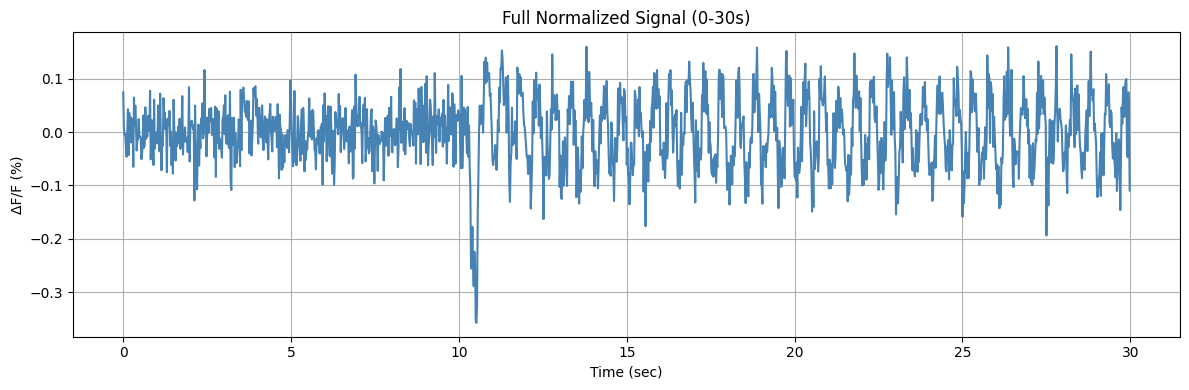

In [ ]:
##### 1.1A - Plot Full Signal (0-30s) #####

plt.figure(figsize=(12, 4))
plt.plot(t, signal, color='steelblue')
plt.title('Full Normalized Signal (0-30s)')
plt.xlabel('Time (sec)')
plt.ylabel('ΔF/F (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

Figure 2: Noise part (Baseline)


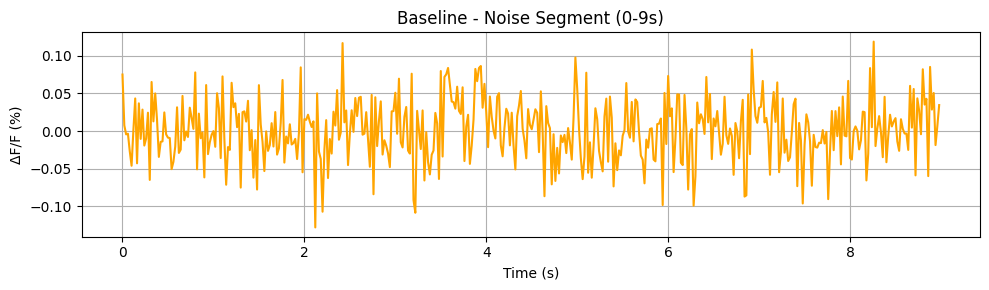

In [ ]:
##### 1.1A - Plot Noise Segment (0-9s) #####

plt.figure(figsize=(10, 3))
plt.plot(t_noise, noise_signal, color='orange')
plt.title('Baseline - Noise Segment (0-9s)')
plt.xlabel('Time (s)')
plt.ylabel('ΔF/F (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

Figure 3: Stimulus part

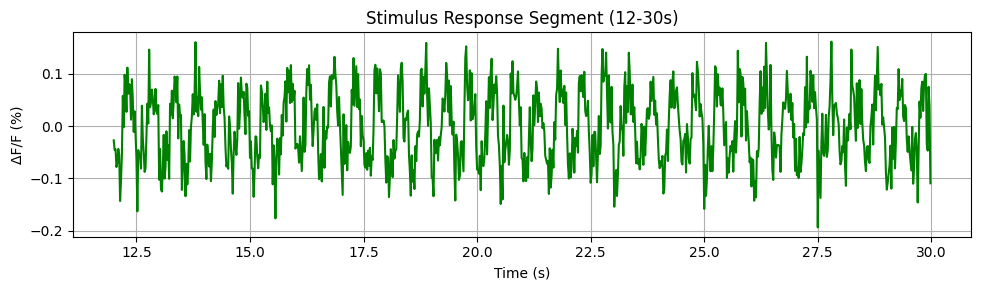

In [ ]:
##### 1.1A - Plot Stimulus Segment (12-30s) #####

plt.figure(figsize=(10, 3))
plt.plot(t_stim, stim_signal, color='green')
plt.title('Stimulus Response Segment (12-30s)')
plt.xlabel('Time (s)')
plt.ylabel('ΔF/F (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 1.1B - Manual signal resampling

Manually resample the signal part (resampled_signal = data [::int])
and plot the stimulus part at the following sampling frequencies: 25, 10, 3 1/3 Hz.

The original sampling frequency was 50 Hz.

To resample to a new frequency (fs_new), we take every 'n-th' sample (step).

  Alias formula:
  f_alias = min |f_signal - N * actual_fs|

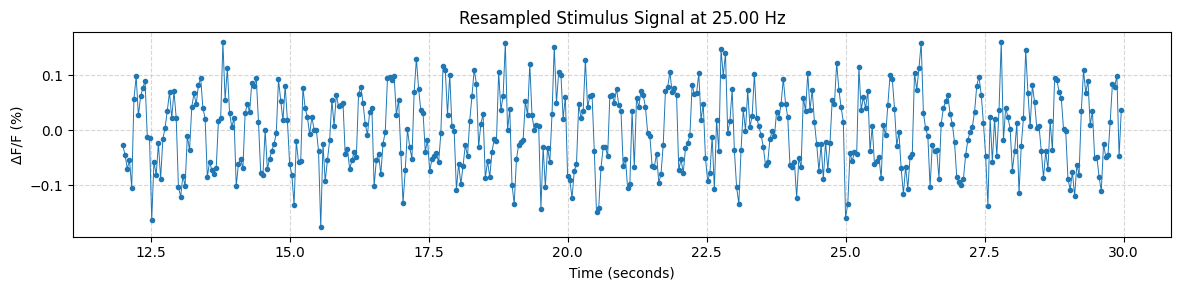

Resampled Fs: 25.000 Hz
Step size: 2
Actual Fs: 25.000 Hz
Number of samples after resampling: 450
------------------------------------------------------------------------------------------


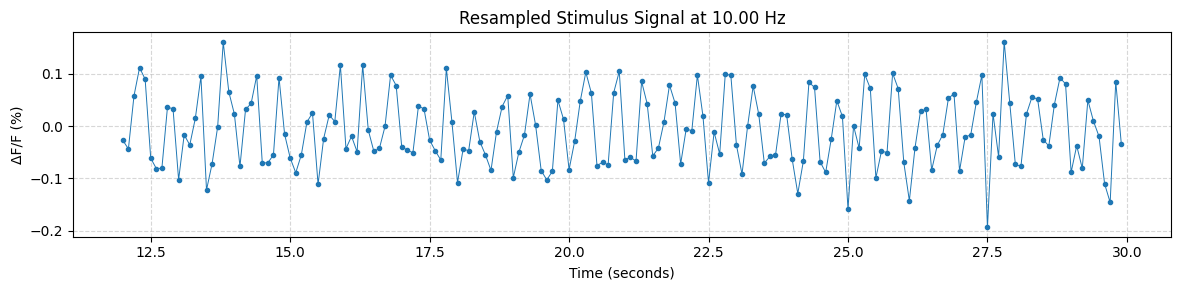

Resampled Fs: 10.000 Hz
Step size: 5
Actual Fs: 10.000 Hz
Number of samples after resampling: 180
------------------------------------------------------------------------------------------


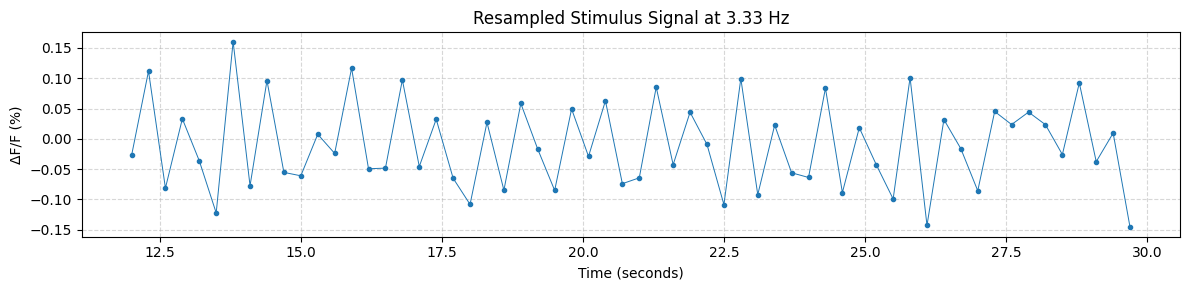

Resampled Fs: 3.333 Hz
Step size: 15
Actual Fs: 3.333 Hz
Number of samples after resampling: 60
------------------------------------------------------------------------------------------


In [ ]:
##### 1.1B - Manual Signal Resampling (Aliasing Demo) #####

# Target frequencies: 25, 10, and 3.33 (10/3) Hz

target_freqs = [25, 10, 10/3]

# Store resampled data so we can reuse it in Part C
resampled_results = {}

for fs_new in target_freqs:

    # Calculate step size - how many original samples to skip
    step = int(fs / fs_new)

    # Resample by taking every n-th sample
    resampled_signal = stim_signal[::step]
    t_resampled = t_stim[::step]

    # Calculate the actual sampling rate after taking every n-th sample
    actual_fs = fs / step

    # Store results for Part C
    resampled_results[fs_new] = {
        "step": step,
        "actual_fs": actual_fs,
        "signal": resampled_signal,
        "time": t_resampled
    }

     # Plot for manual peak counting
    plt.figure(figsize=(12, 3))
    plt.plot(t_resampled, resampled_signal, marker='.', linestyle='-', linewidth=0.7)

    plt.title(f"Resampled Stimulus Signal at {actual_fs:.2f} Hz")
    plt.xlabel("Time (seconds)")
    plt.ylabel("ΔF/F (%)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f"Resampled Fs: {fs_new:.3f} Hz")
    print(f"Step size: {step}")
    print(f"Actual Fs: {actual_fs:.3f} Hz")
    print(f"Number of samples after resampling: {len(resampled_signal)}")
    print("-" * 90)

## 1.1 C - Aliasing calculation and manual frequency estimation

For each resampled signal, calculate falias and estimate the main frequency by counting the number of clear peaks in the signal. Does the plotted frequency match your calculation? Explain.

In [ ]:
##### 1.1C - Aliasing Calculation and Manual Frequency Estimation #####
# True frequency of the stimulus
f_signal = 2.0  # Hz
min_sampling_rate = 2 * f_signal   # 4 Hz

print(f"The true stimulus frequency is {f_signal:.1f} Hz.")
print(f"the minimum sampling rate required by Nyquist is {min_sampling_rate:.1f} Hz.\n")

# Enter the manual number of clear peaks counted from Part B
manual_peak_counts = {
    25: 36,
    10: 36,
    10/3: 24
}

for fs_new in target_freqs:
    actual_fs = resampled_results[fs_new]["actual_fs"]
    N = round(f_signal / actual_fs)
    f_alias = abs(f_signal - N * actual_fs)
    manual_peaks = manual_peak_counts[fs_new]
    f_estimated = manual_peaks / stim_duration

    if actual_fs > min_sampling_rate:
        conclusion = "Above minimum sampling rate: no aliasing is expected."
    else:
        conclusion = "Below minimum sampling rate: aliasing is expected."

    print(f"Fs = {actual_fs:.3f} Hz: f_alias = {f_alias:.3f} Hz, peaks = {manual_peaks}, f_estimated = {f_estimated:.3f} Hz. \n{conclusion}\n")

The true stimulus frequency is 2.0 Hz.
the minimum sampling rate required by Nyquist is 4.0 Hz.

Fs = 25.000 Hz: f_alias = 2.000 Hz, peaks = 36, f_estimated = 2.000 Hz. 
Above minimum sampling rate: no aliasing is expected.

Fs = 10.000 Hz: f_alias = 2.000 Hz, peaks = 36, f_estimated = 2.000 Hz. 
Above minimum sampling rate: no aliasing is expected.

Fs = 3.333 Hz: f_alias = 1.333 Hz, peaks = 24, f_estimated = 1.333 Hz. 
Below minimum sampling rate: aliasing is expected.



SUMMERY

Minimum sampling rate: 4 Hz

Frequency seen at 3.33Hz sampling: 1.33 Hz - aliasing

Frequency seen at 10Hz sampling: 2 Hz

Frequency seen at 25Hz sampling: 2 Hz

## 1.1 D - Minimum number of bits for quantization

To record the neural dynamics properly, we need to distinguish between changes of 0.1% in intensity power (for example, if the original signal at f(t) = 6000, then f(t+1) needs to be 6006 to consider it a spike (assuming no noise). What is the minimum number of bits needed to distinguish action potentials, assuming no noise? Explain.

In [ ]:
##### 1.1D - Quantization Bits Calculation #####
# Define the required resolution (0.1% = 0.001)
required_resolution_fraction = 0.001

# According to the quantization resolution formula:
# B = log2(R / Q)
# R / Q = 1 / 0.001 = 1000
ratio = 1 / required_resolution_fraction

# Calculate the minimum number of bits
min_bits = int(np.ceil(np.log2(ratio)))   # round up using np.ceil()

# Print results
print(f"Required resolution fraction: {required_resolution_fraction * 100}% (1 part in {ratio:.0f})")
print(f"Minimum bits required: {min_bits}")

Required resolution fraction: 0.1% (1 part in 1000)
Minimum bits required: 10


# Part 2: Noise Reduction

## 2.1 - SNRrms Calculation

Calculate the SNRrms of the signal in 1.1 in two different ways we learned in class. Explain your calculations. (Reminder: the signal part contains noise too; the noise has zero mean and is uncorrelated with the signal). Are the results different? Explain.

In [ ]:
##### 2.1 - SNRrms Calculation (Power vs Mean/Std) #####
# --- Method 1: Power-based SNRrms ---
# Power is the mean of the squared values: (1/n) * sum(x^2)

noise_power = np.mean(noise_signal**2)
stim_power = np.mean(stim_signal**2)

# SNRrms = sqrt(Signal_Power / Noise_Power) - 1
# Subtract 1 to account for noise being present in the stimulus power
snr_rms_method1 = np.sqrt((stim_power / noise_power)-1)

# --- Method 2: Mean / Standard Deviation ---
# Signal is estimated by the mean, Noise by the standard deviation
mean_signal = np.mean(stim_signal)
std_noise = np.std(noise_signal)

# SNRrms = mean(signal) / std(noise)
snr_rms_method2 = mean_signal / std_noise

# --- Print Results ---
print(f"SNRrms - Method 1 (Power Ratio): {snr_rms_method1:.4f}")
print(f"SNRrms - Method 2 (Mean/Std): {snr_rms_method2:.4f}")

SNRrms - Method 1 (Power Ratio): 1.3376
SNRrms - Method 2 (Mean/Std): -0.0231


## 2.2 - Noise Reduction by Block Averaging

Reduce the noise by averaging each 2, 3, 5 points (not a moving window). Plot each new signal and calculate its SNR using √((〖Signal〗^2-Noise^2)/(Noise^2 )). Explain the improvement factor.


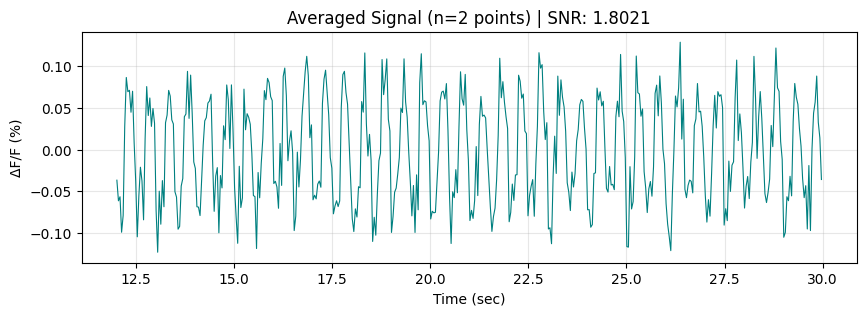

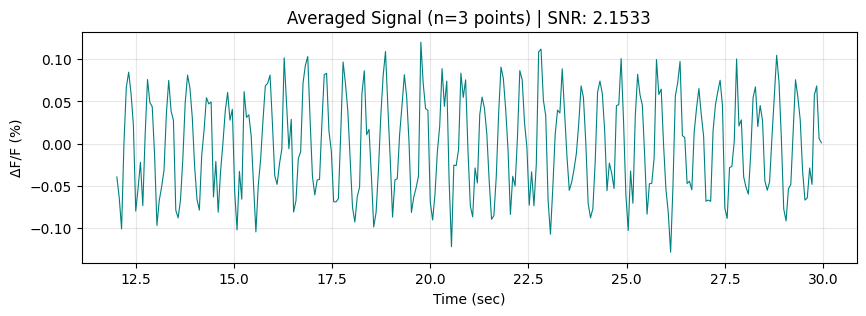

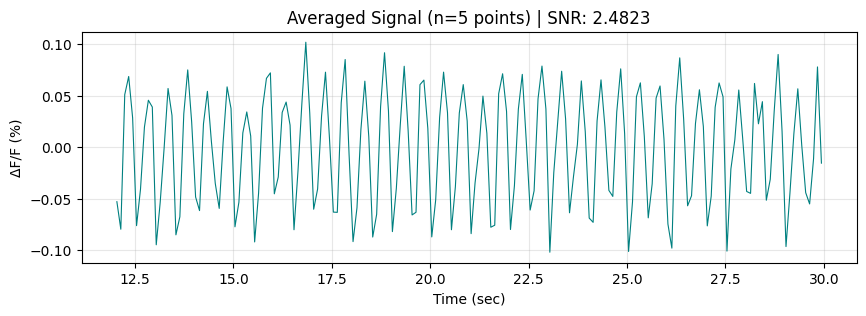

In [ ]:
##### 2.2 - Noise Reduction by Block Averaging (n=2, 3, 5) #####
def block_average(data, n):
    n_blocks = len(data) // n
    trimmed_data = data[:n_blocks * n]
    averaged_data = trimmed_data.reshape(-1, n).mean(axis=1)
    return averaged_data

n_values = [2, 3, 5]
original_snr = snr_rms_method1
averaging_results = {}

for n in n_values:
    avg_noise = block_average(noise_signal, n)
    avg_stim = block_average(stim_signal, n)
    avg_t_stim = block_average(t_stim, n)
    snr_avg = np.sqrt((np.mean(avg_stim**2) / np.mean(avg_noise**2)) - 1)
    averaging_results[n] = {"snr": snr_avg, "improvement": snr_avg / original_snr}

    plt.figure(figsize=(10, 3))
    plt.plot(avg_t_stim, avg_stim, color='teal', linewidth=0.8)
    plt.title(f'Averaged Signal (n={n} points) | SNR: {snr_avg:.4f}')
    plt.xlabel('Time (sec)')
    plt.ylabel('ΔF/F (%)')
    plt.grid(True, alpha=0.3)
    plt.show()

Unified Comparison: Block Averaging (N=2, 3, 5)

Here we compare all the averaging factors in a single plot for a direct visual comparison of noise reduction.

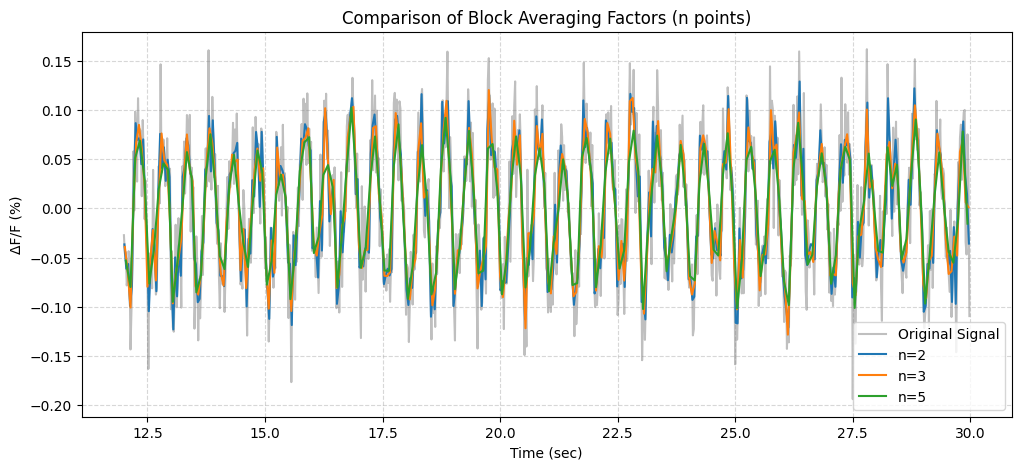

In [ ]:
##### 2.2 - Unified Comparison: Block Averaging #####

plt.figure(figsize=(12, 5))

# Plot original stimulus signal
plt.plot(t_stim, stim_signal, label='Original Signal', alpha=0.5, color='gray')

# Plot each averaged signal
# colors = ['blue', 'pink', 'green']
for i, n in enumerate(n_values):
    avg_stim = block_average(stim_signal, n)
    avg_t_stim = block_average(t_stim, n)
    plt.plot(avg_t_stim, avg_stim, label=f'n={n}', linewidth=1.5)

plt.title('Comparison of Block Averaging Factors (n points)')
plt.xlabel('Time (sec)')
plt.ylabel('ΔF/F (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()
plt.show()

## 2.3 - Reduced signal by 20-points kernel

Reduce signal noise by applying a 20-point averaging kernel (not a moving window), then plot the signal. Explain why we can no longer see the original oscillations.

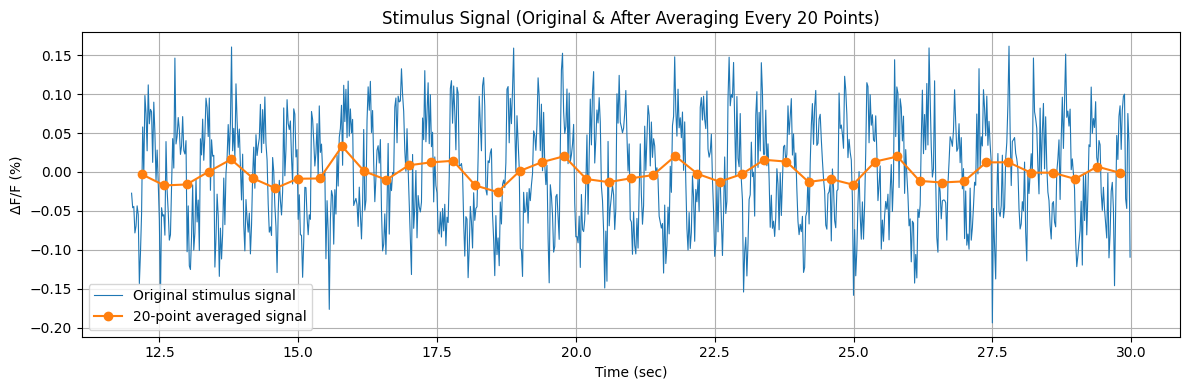

Signal: 2.0 Hz | Period: 0.50s
Averaging Window: 20 pts | Duration: 0.40s
New Sampling Rate: 2.50 Hz | Min Required: 4.00 Hz

--- Final Conclusion ---
Under-sampling detected (New Fs < 4Hz).
The signal is lost because the averaging window (0.4s)
is too close to the signal's period (0.5s), causing phase cancellation.


In [ ]:
##### 2.3 - Noise Reduction by 20-Point Block Averaging #####

n = 20

# Apply block averaging to the stimulus signal
avg_stim_20 = block_average(stim_signal, n)

# Average the time vector in the same way
avg_t_stim_20 = block_average(t_stim, n)

# Calculate important theoretical values
new_fs_20 = fs / n
block_duration = n / fs

f_signal = 2.0
signal_period = 1 / f_signal
min_sampling_rate = 2 * f_signal

# Plot original and averaged stimulus signal
plt.figure(figsize=(12, 4))
plt.plot(t_stim, stim_signal, label='Original stimulus signal', linewidth=0.8)
plt.plot(avg_t_stim_20, avg_stim_20, marker='o', label='20-point averaged signal')

plt.title('Stimulus Signal (Original & After Averaging Every 20 Points)')
plt.xlabel('Time (sec)')
plt.ylabel('ΔF/F (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print explanation values
print(f"Signal: {f_signal} Hz | Period: {signal_period:.2f}s")
print(f"Averaging Window: {n} pts | Duration: {block_duration:.2f}s")
print(f"New Sampling Rate: {new_fs_20:.2f} Hz | Min Required: {min_sampling_rate:.2f} Hz")

print("\n--- Final Conclusion ---")
if new_fs_20 < min_sampling_rate:
    print("Under-sampling detected (New Fs < 4Hz).")
    print(f"The signal is lost because the averaging window ({block_duration:.1f}s)\nis too close to the signal's period ({signal_period:.1f}s), causing phase cancellation.")
else:
    print("RESULT: Signal structure preserved.")

## 2.4 - Rectangular Kernel Smoothing (window size 3 x 2)

Perform 2 times moving average smoothing using a rectangular kernel of size 3 on the original signal.

rectangle smoothing of size 3: [0.33333333 0.33333333 0.33333333]
Original stimulus length: 900
Smoothed stimulus length: 900



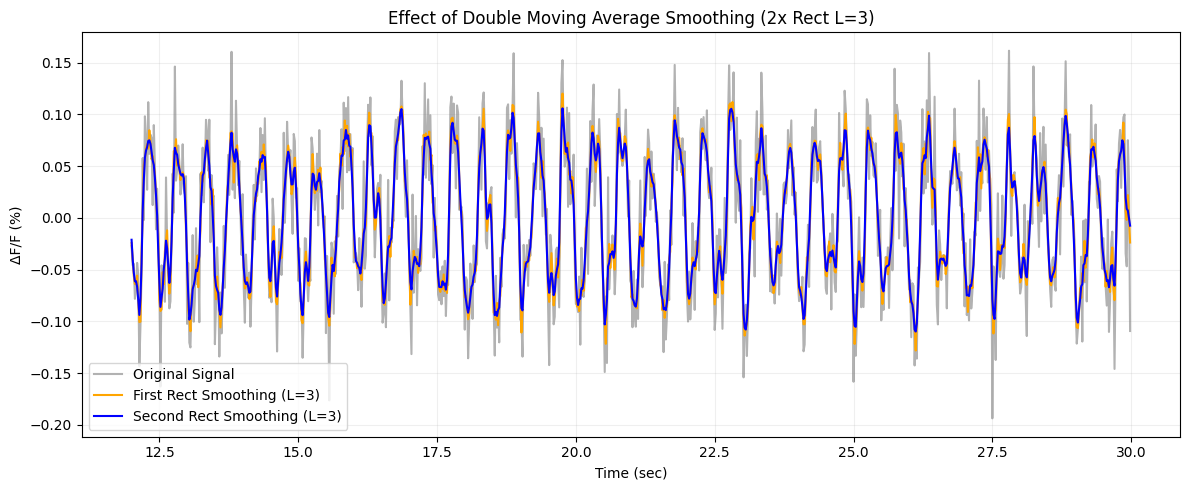

In [ ]:
##### 2.4 - Double Moving Average Smoothing - window size 3 #####

def moving_average(data, L):
    """
    Applies a moving average filter with window size L.
    Returns: (smoothed_data, rect_kernel)
    """
    # Create a rectangular kernel and normalize it so the sum is 1
    rect_kernel = np.ones(L) / L

    # Apply convolution and keep the output length the same as the input
    smoothed_data = np.convolve(data, rect_kernel, mode='same')
    return smoothed_data, rect_kernel

# Define rectangular window size
L_rect = 3

# --- Perform smoothing 2 times ---
# First pass: returns smoothed data and the kernel used
first_pass, rect_kernel_vals = moving_average(stim_signal, L_rect)

# Second pass: apply the same filter to the result of the first pass
double_smoothed, _ = moving_average(first_pass, L_rect)

# Save result for Part 2.6
rect_smoothed = double_smoothed

# Print verification
print(f"rectangle smoothing of size {L_rect}: {rect_kernel_vals}")
print(f"Original stimulus length: {len(stim_signal)}")
print(f"Smoothed stimulus length: {len(rect_smoothed)}")
print()

# Plot the results - ONLY FOR VISUALIZATION
plt.figure(figsize=(12, 5))
plt.plot(t_stim, stim_signal, color='gray', alpha=0.6, label='Original Signal')
plt.plot(t_stim, first_pass, color='orange', linewidth=1.5, label='First Rect Smoothing (L=3)')
plt.plot(t_stim, double_smoothed, color='blue', linewidth=1.5, label='Second Rect Smoothing (L=3)')

plt.title('Effect of Double Moving Average Smoothing (2x Rect L=3)')
plt.xlabel('Time (sec)')
plt.ylabel('ΔF/F (%)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 2.5 - Triangular Kernel Smoothing (window size 5)

In [ ]:
##### 2.5 - Moving average smoothing with triangular kernel #####

def triangular_moving_average(data):
    """
    Applies a moving average filter with a triangular kernel of size 5.
    Returns: (smoothed_data, triangle_kernel)
    """
    # Create a triangular kernel of size 5
    triangle_kernel = np.array([1, 2, 3, 2, 1])

    # Normalize the kernel so the sum of the coefficients is 1
    triangle_kernel = triangle_kernel / np.sum(triangle_kernel)

    # Apply convolution and keep the output length the same as the input
    smoothed_data = np.convolve(data, triangle_kernel, mode='same')

    return smoothed_data, triangle_kernel


# Apply triangular smoothing to the original stimulus signal
triangular_smoothed, triangle_kernel_vals = triangular_moving_average(stim_signal)

# Save result for Part 2.6
tri_smoothed = triangular_smoothed

# Print verification
print(f"triangular smoothing of size 5: {triangle_kernel_vals}")
print(f"Kernel sum: {np.sum(triangle_kernel_vals):.1f}")
print(f"Original stimulus length: {len(stim_signal)}")
print(f"Smoothed stimulus length: {len(tri_smoothed)}")

triangular smoothing of size 5: [0.11111111 0.22222222 0.33333333 0.22222222 0.11111111]
Kernel sum: 1.0
Original stimulus length: 900
Smoothed stimulus length: 900


## 2.6 - Plotting Smoothing Comparison: Original vs 2x Rect vs Triangular


Plot the original, the rectangular-smoothed, and the triangular-smoothed signal and compare it.

Mathematically, applying a rectangular filter of size $L$ twice is equivalent to applying a triangular filter of size $2L-1$ once

The general rule: n passes with a rectangular window of size w is the same as one pass with a triangular window of : 2*(3-1)+1 = 5.

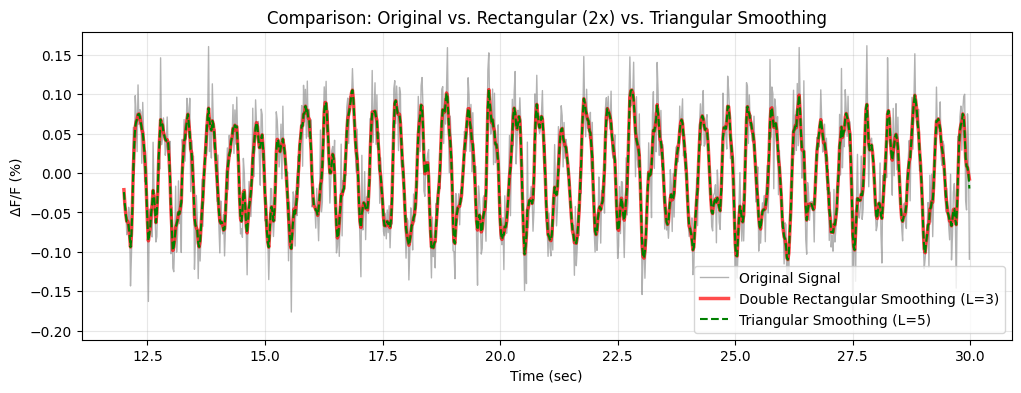

Maximum difference between the two smoothing methods, excluding edges: 2.78e-17


In [ ]:
##### 2.6 - Plotting Comparison: Original vs 2x Rect vs Triangular #####

plt.figure(figsize=(12, 4))

# Plot the original noisy signal as a background reference
plt.plot(t_stim, stim_signal, label='Original Signal', color='gray', alpha=0.6, linewidth=1)

# Plot the double rectangular smoothing (L=3 twice)
plt.plot(t_stim, rect_smoothed, label='Double Rectangular Smoothing (L=3)', linewidth=2.5, color='red', alpha=0.7)

# Plot the triangular smoothing (L=5)
plt.plot(t_stim, tri_smoothed, label='Triangular Smoothing (L=5)', linestyle='--', linewidth=1.5, color='green')

plt.title('Comparison: Original vs. Rectangular (2x) vs. Triangular Smoothing')
plt.xlabel('Time (sec)')
plt.ylabel('ΔF/F (%)')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.tight_layout()   # delete "#" to activate if wanted
plt.show()

difference = np.abs(rect_smoothed[2:-2] - tri_smoothed[2:-2]).max()
print(f"Maximum difference between the two smoothing methods, excluding edges: {difference:.2e}")

## 2.7	Explain why smoothing is considered a "Low-Pass Filter."

The smoothing operation is considered a low-pass filter because for each moving average, it calculates the weighted value of each point and its neighbors. This process offsets and filters out rapid, random changes in amplitude, which characterize high-frequency fluctuations (such as random noise). Conversely, long-term and slow trends of the signal (low-frequency fluctuations, such as the stimulus oscillations at 2 Hz) are barely affected. As a result, low frequencies successfully "pass" through the filter, while high frequencies are attenuated and smoothed out.

# Part 3: Spike train analysis

Use the spike_trains.csv provided.

It contains 100 trials of binary data (1 = spike, 0 = no spike) of 5 neurons, A and B, C, D and E, recorded for 30 seconds with a sampling frequency of 1000 Hz.

## 3.1

### A -	Calculate the Mean Firing Rate (Hz) for each neuron over trials.

In [ ]:
##### 3.1A - Mean Firing Rate (Vectorized Version) #####

# Print basic information to verify the file structure
print(df_spike_trains.head())

# --- Define experimental constants ---
fs_spikes = 1000          # Sampling frequency [Hz]
trial_duration = 30       # Duration of a single trial [seconds]

# Identify only the numeric time columns ('0' to '29999')
time_cols = [col for col in df_spike_trains.columns if col.isdigit()]

# Create a temporary labels Series for grouping rows by neuron
# Example: "1_A" -> "A"
temp_neuron_labels = df_spike_trains['trial_neuron'].str.split('_').str[1]

# Store results for later
mean_firing_rates = {}
neuron_data_dict = {}   # Each value is a matrix: trial x time bin

print("\n--- Part 3.1A: Mean Firing Rates Over Trials ---")

# Group the original DataFrame using the temporary neuron labels
for neuron, group in df_spike_trains.groupby(temp_neuron_labels):

    # Extract only the spike columns of the current neuron
    # Rows = trials, columns = time bins
    neuron_data = group[time_cols].to_numpy()   # shape: (100, 30000)

    # Save the neuron's full trial data for later sections
    neuron_data_dict[neuron] = neuron_data

    # Count total spikes across all trials and all time bins
    total_spikes = neuron_data.sum()
    # Calculate total recording time for this neuron
    num_trials_neuron = neuron_data.shape[0]   # 100 trials
    total_duration_sec = num_trials_neuron * trial_duration # 100 * 30 = 3000s

    # Mean Firing Rate [Hz] = total spikes / total recording time
    mean_fr_neuron = total_spikes / total_duration_sec

    # Save result
    mean_firing_rates[neuron] = mean_fr_neuron

    # Print result
    print(f"Neuron {neuron}: Mean Firing Rate = {mean_fr_neuron:.2f} Hz")

  trial_neuron  0  1  2  3  4  5  6  7  8  ...  29990  29991  29992  29993  \
0          1_A  0  0  0  0  0  0  0  0  0  ...      0      0      0      0   
1          1_B  0  0  0  0  0  0  0  0  0  ...      0      0      0      0   
2          1_C  0  0  1  0  0  0  0  0  0  ...      0      0      0      0   
3          1_D  1  0  0  0  0  0  0  0  0  ...      0      0      0      0   
4          1_E  0  0  1  0  0  1  0  0  1  ...      0      1      0      0   

   29994  29995  29996  29997  29998  29999  
0      0      0      0      1      0      0  
1      0      0      0      0      0      1  
2      0      1      0      0      0      0  
3      0      0      0      0      0      0  
4      1      0      0      1      0      0  

[5 rows x 30001 columns]

--- Part 3.1A: Mean Firing Rates Over Trials ---
Neuron A: Mean Firing Rate = 11.67 Hz
Neuron B: Mean Firing Rate = 42.55 Hz
Neuron C: Mean Firing Rate = 100.00 Hz
Neuron D: Mean Firing Rate = 49.98 Hz
Neuron E: Mean Firing Rate

### B -	Calculate the Fano Factor (FF) (Var / Mean) for the spike counts using a fixed 1 second window over trials for each neuron.

In [ ]:
##### 3.1B - Fano Factor (Fixed 1-Second Window Over Trials) #####

# --- Choose one fixed 1-second window ---
window_start_sec = 0
window_size_sec = 1

# Convert to sampling idx
window_start_bin = int(window_start_sec * fs_spikes)    # = 0
window_end_bin = int((window_start_sec + window_size_sec) * fs_spikes)    # = 1000

print("--- Part 3.1B: Fano Factor Calculation (Fixed 1-Sec Window) ---")
print(f"\nSelected window: {window_start_sec}-{window_start_sec + window_size_sec} sec")

# Select the time columns that belong to the chosen 1-second window
window_cols = time_cols[window_start_bin:window_end_bin]

# Create a temporary DataFrame for this section only
# This keeps df_spike_trains unchanged for the next sections
df_fano = pd.DataFrame()

# Count spikes in the selected 1-second window for each trial
# Each row is one trial of one neuron
df_fano['counts_1sec'] = df_spike_trains[window_cols].sum(axis=1)

# Group rows by neuron
# Create a column named 'neuron'. Example: "1_A" -> "A"
df_fano['neuron'] = df_spike_trains['trial_neuron'].str.split('_').str[1]

# Calculate mean, variance, and Fano Factor for each neuron
ff_clac = df_fano.groupby('neuron')['counts_1sec'].agg(['mean', 'var'])
ff = ff_clac['Fano_Factor'] = ff_clac['var'] / ff_clac['mean']

print("\n",ff_clac)

--- Part 3.1B: Fano Factor Calculation (Fixed 1-Sec Window) ---

Selected window: 0-1 sec

           mean         var  Fano_Factor
neuron                                 
A        11.80   11.636364     0.986133
B        42.64   24.515556     0.574943
C       100.00    0.000000     0.000000
D        49.93    0.510202     0.010218
E        27.76  184.709495     6.653800


### C - Which type of neuron A is? Explain in relation to the FF

In [ ]:
##### 3.1C - Result Verification (Fano Factor) #####
print("--- Part 3.1C: Fano Factor Summary ---")
print(ff)

--- Part 3.1C: Fano Factor Summary ---
neuron
A    0.986133
B    0.574943
C    0.000000
D    0.010218
E    6.653800
dtype: float64


Based on the calculation in section 3.1B, **Neuron A** is a **Poisson neuron**.


The Fano Factor (FF) for Neuron A is approximately **0.986**, which is very close to **1**.
In a Poisson process, the variance of the count is equal to its mean ($Var = Mean$), leading to a Fano Factor of 1. A FF close to 1 indicates that the neuron fires with stochastic (random) timing, where each spike is independent of the previous one.

### D -	plot the ISI distribution for neurons A and B. Explain both plots. What are the differences?

--- Part 3.1D: ISI Distribution ---

Neuron A: Mean ISI = 85.47 ms
Neuron B: Mean ISI = 23.49 ms


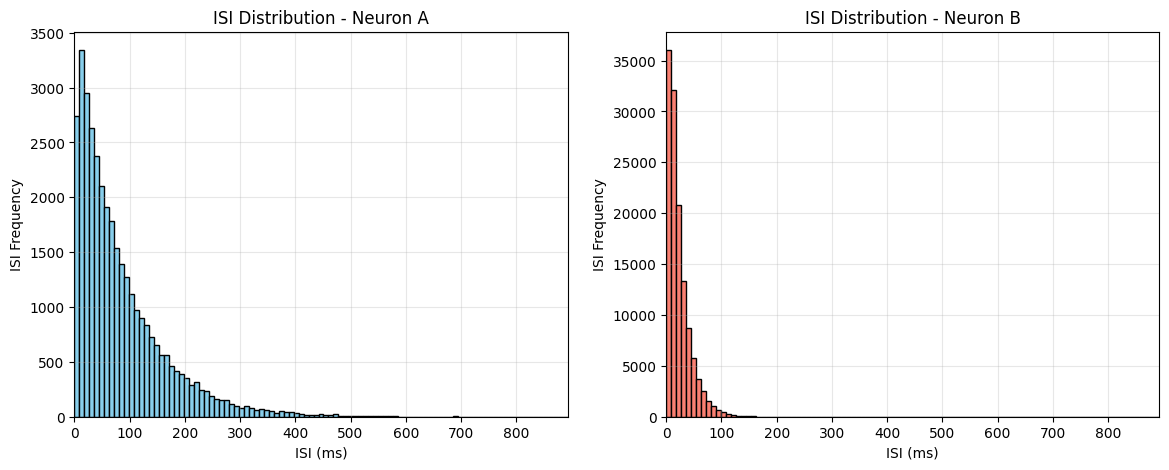

In [ ]:
##### 3.1D - ISI Distribution for Neurons A and B #####

def get_isi(neuron_key):
    # Extract data for the specific neuron
    # data shape: trials x time bins
    data = neuron_data_dict[neuron_key]

    all_isi = []

    for trial in range(data.shape[0]):    # 100 trials
        # Find indices (time bins) where a spike occurred
        spike_indices = np.where(data[trial] == 1)[0]

        # Calculate differences between consecutive spikes
        if len(spike_indices) > 1:
        # Convert from sample bins to milliseconds:
        # samples / samples-per-second = seconds, then *1000 = milliseconds
          isi = (np.diff(spike_indices) / fs_spikes) * 1000
          all_isi.extend(isi)

    return np.array(all_isi)

# Calculate ISIs for neurons A and B
isi_A = get_isi('A')
isi_B = get_isi('B')

print("--- Part 3.1D: ISI Distribution ---")
print(f"\nNeuron A: Mean ISI = {np.mean(isi_A):.2f} ms")
print(f"Neuron B: Mean ISI = {np.mean(isi_B):.2f} ms")

# Create identical bins for both neurons
max_isi = max(np.max(isi_A), np.max(isi_B))
bins = np.linspace(0, max_isi, 100)

# Create the plots
plt.figure(figsize=(14, 5))

# Plot Neuron A
plt.subplot(1, 2, 1)
plt.hist(isi_A, bins=bins, color='skyblue', edgecolor='black')
plt.title('ISI Distribution - Neuron A')
plt.xlabel('ISI (ms)')
plt.ylabel('ISI Frequency')
plt.grid(alpha=0.3)
plt.xlim(0, max_isi)

# Plot Neuron B
plt.subplot(1, 2, 2)
plt.hist(isi_B, bins=bins, color='salmon', edgecolor='black')
plt.title('ISI Distribution - Neuron B')
plt.xlabel('ISI (ms)')
plt.ylabel('ISI Frequency')
plt.grid(alpha=0.3)
plt.xlim(0, max_isi)

# plt.tight_layout()   # delete "#" to activate if wanted
plt.show()

Explanation of ISI Plots and Differences:

1. **Neuron A (Poisson):** The distribution follows an **Exponential decay** shape. This is the hallmark of a Poisson process, where the timing of the next spike is independent of the previous one. Most intervals are very short, but there is a long "tail" of longer intervals.

2. **Neuron B:** The distribution shows a more **Gaussian-like (Normal)** or peaked shape centered around its mean firing rate. This indicates a more regular or rhythmic firing pattern compared to Neuron A.

Main Differences:
* **Regularity:** Neuron B is much more regular. Its spikes occur at somewhat predictable intervals.
* **Shape:** Neuron A's exponential shape confirms its stochastic nature, while Neuron B's peaked distribution suggests an internal mechanism or stimulus that enforces **higher** and a more **consistent** firing frequency.

### E -	Plot a raster plot for each neuron A, C, D and E, zooming in on the first second

--- Part 3.1E: Raster Plots - First Second ---

Selected window: 0-1 sec



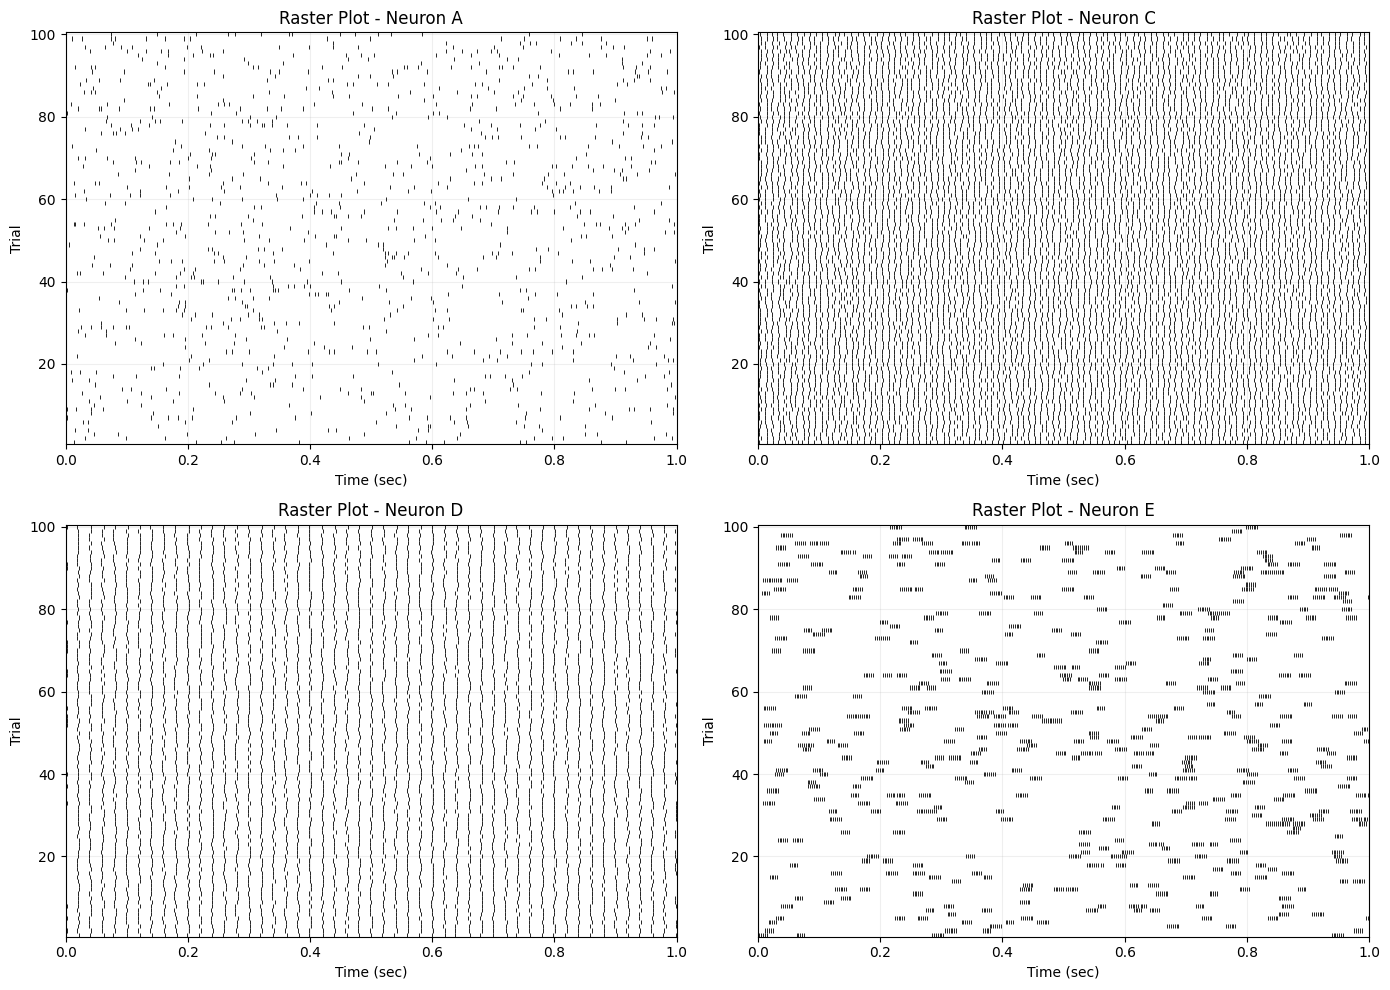

In [ ]:
##### 3.1E - Raster Plot for Neurons A, C, D and E (first second) #####

# Define the time window to plot
raster_start_sec = 0
raster_end_sec = 1

# Convert seconds to sample indices
raster_start_bin = int(raster_start_sec * fs_spikes)    # 0 * 1000 = 0
raster_end_bin = int(raster_end_sec * fs_spikes)    # 1 * 1000 = 1000

# Neurons required in the question
neurons_to_plot = ['A', 'C', 'D', 'E']

print("--- Part 3.1E: Raster Plots - First Second ---")
print(f"\nSelected window: {raster_start_sec}-{raster_end_sec} sec\n")
# Create one figure with 4 subplots
plt.figure(figsize=(14, 10))

for i, neuron in enumerate(neurons_to_plot):

    # Extract the data of the current neuron
    data = neuron_data_dict[neuron]   # data shape: trials x time bins

    # Take only the first second
    data_first_sec = data[:, raster_start_bin:raster_end_bin]

    # Create 4 subplot
    plt.subplot(2, 2, i + 1)

    # Loop over trials
    for trial in range(data_first_sec.shape[0]):

        # Find spike times in the current trial
        spike_bins = np.where(data_first_sec[trial] == 1)[0]

        # Convert spike bins to time in seconds
        spike_times_sec = spike_bins / fs_spikes

        # Plot each spike as a small vertical line
        plt.vlines(
            spike_times_sec,
            trial + 0.5,
            trial + 1.5,
            color='black',
            linewidth=0.6
        )

    plt.title(f'Raster Plot - Neuron {neuron}')
    plt.xlabel('Time (sec)')
    plt.ylabel('Trial')
    plt.xlim(raster_start_sec, raster_end_sec)
    plt.ylim(0.5, data_first_sec.shape[0] + 0.5)
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### F - Which type of neuron E is? Explain in relation to the raster plot

From the Raster plot of **Neuron E**, we can observe a non-continuous firing pattern where spikes appear in clusters (very dense bursts), followed by periods of complete silence where the neuron does not fire at all.

In section B, I calculated the Fano Factor (FF) for Neuron E, which resulted in a value significantly greater than 1 (**FF ≈ 6.65**). As described in section C, this firing pattern is characteristic of a **Bursting neuron**, which exhibits high variance relative to the mean.

### G -	Plot the PSTH of neuron A and D (zooming in on the first second). Normalize the y-axis to the firing rate in Hz.
 Explain why the peaks of the signal for neuron D are higher than the firing rate


--- Part 3.1G: PSTH - First Second ---

Selected window: 0-1 sec

Neuron A:
Mean firing rate in first second = 11.80 Hz
Peak PSTH value = 60.00 Hz

Neuron D:
Mean firing rate in first second = 49.93 Hz
Peak PSTH value = 310.00 Hz



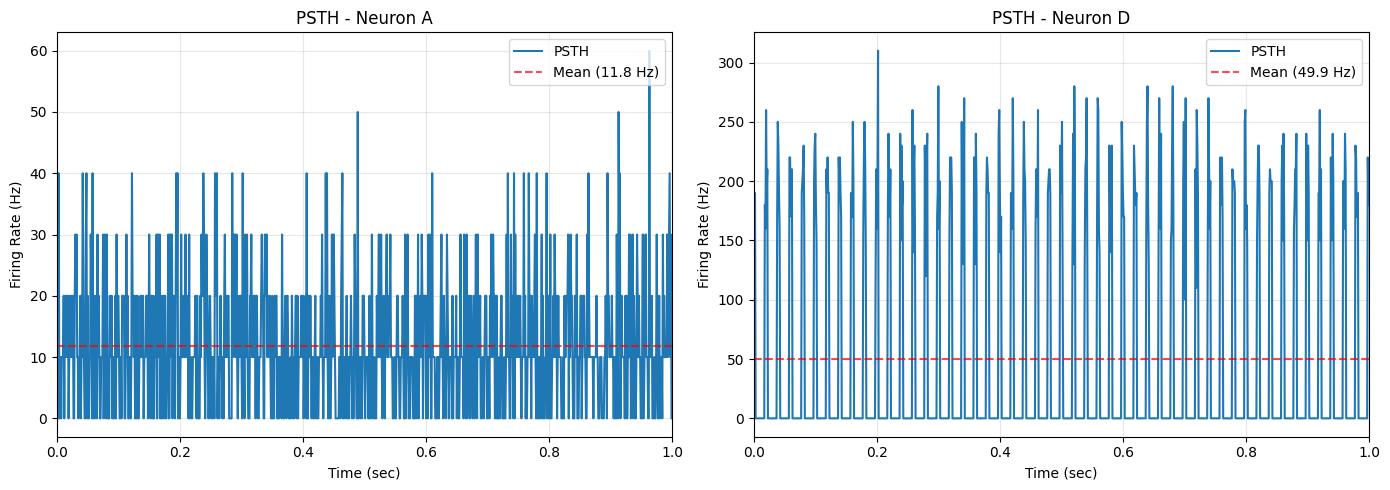

In [ ]:
##### 3.1G - PSTH for Neurons A and D (first second) #####

# Define the time window to plot
psth_start_sec = 0
psth_end_sec = 1

# Convert seconds to sample indices
psth_start_bin = int(psth_start_sec * fs_spikes)
psth_end_bin = int(psth_end_sec * fs_spikes)

# Neurons required in the question
neurons_to_plot = ['A', 'D']

print("--- Part 3.1G: PSTH - First Second ---")
print(f"\nSelected window: {psth_start_sec}-{psth_end_sec} sec\n")

plt.figure(figsize=(14, 5))

for i, neuron in enumerate(neurons_to_plot):

    # Extract the data of the current neuron
    data = neuron_data_dict[neuron]   # data shape: trials x time bins

    # Take only the first second
    data_first_sec = data[:, psth_start_bin:psth_end_bin]

    # Number of trials
    num_trials = data_first_sec.shape[0]

    # Calculate the probability of spiking in each time bin across trials
    # Mean over trials: for each time bin, what fraction of trials had a spike
    spike_probability_per_bin = np.mean(data_first_sec, axis=0)

    # Convert probability per bin to firing rate in Hz
    psth_hz = spike_probability_per_bin * fs_spikes

    # Calculate mean rate for the plot
    mean_rate = np.mean(psth_hz)

    # Create time axis in seconds
    time_axis = np.arange(data_first_sec.shape[1]) / fs_spikes

    # Print useful values
    print(f"Neuron {neuron}:")
    print(f"Mean firing rate in first second = {mean_rate:.2f} Hz")
    print(f"Peak PSTH value = {np.max(psth_hz):.2f} Hz\n")

    # Plot
    plt.subplot(1, 2, i + 1)
    plt.plot(time_axis, psth_hz, label='PSTH')

    # Add horizontal line for the mean
    plt.axhline(mean_rate, color='red', linestyle='--', alpha=0.7, label=f'Mean ({mean_rate:.1f} Hz)')

    plt.title(f'PSTH - Neuron {neuron}')
    plt.xlabel('Time (sec)')
    plt.ylabel('Firing Rate (Hz)')
    plt.xlim(psth_start_sec, psth_end_sec)
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The peaks of **Neuron D** in the PSTH are much higher than its average firing rate because the PSTH represents the **instantaneous firing rate** in very short 1ms bins.

Neuron D exhibits a regular and periodic firing pattern, meaning it tends to fire at very similar times across different trials. Consequently, in many trials, the spikes fall into the same time bins, resulting in a high spike probability at those specific moments. When this probability is normalized to Hz (by multiplying by the 1000Hz sampling rate), we obtain very high instantaneous values.

In contrast, the **average firing rate** is calculated over the entire second and includes the periods of time when the neuron is not firing, which is why it is significantly lower than the sharp instantaneous peaks seen in the PSTH.

##3.2 Correlation Analysis

### A -	Plot the Autocorrelation of the first 2 minutes of Neuron A, C, D and E.
 Normalize the y-axis to show the mean firing rate. Identify the Refractory Period from the plot (zoom into lag0 to make the refractory period visible, at 1 ms resolution).

--- Part 3.2A: Autocorrelation (0-120s) ---

Neuron A: Mean FR = 11.51 Hz |Refractory ≈ 3.0 ms

Neuron C: Mean FR = 100.00 Hz |Refractory ≈ 6.0 ms

Neuron D: Mean FR = 49.99 Hz |Refractory ≈ 16.0 ms

Neuron E: Mean FR = 28.13 Hz |Refractory ≈ 3.0 ms



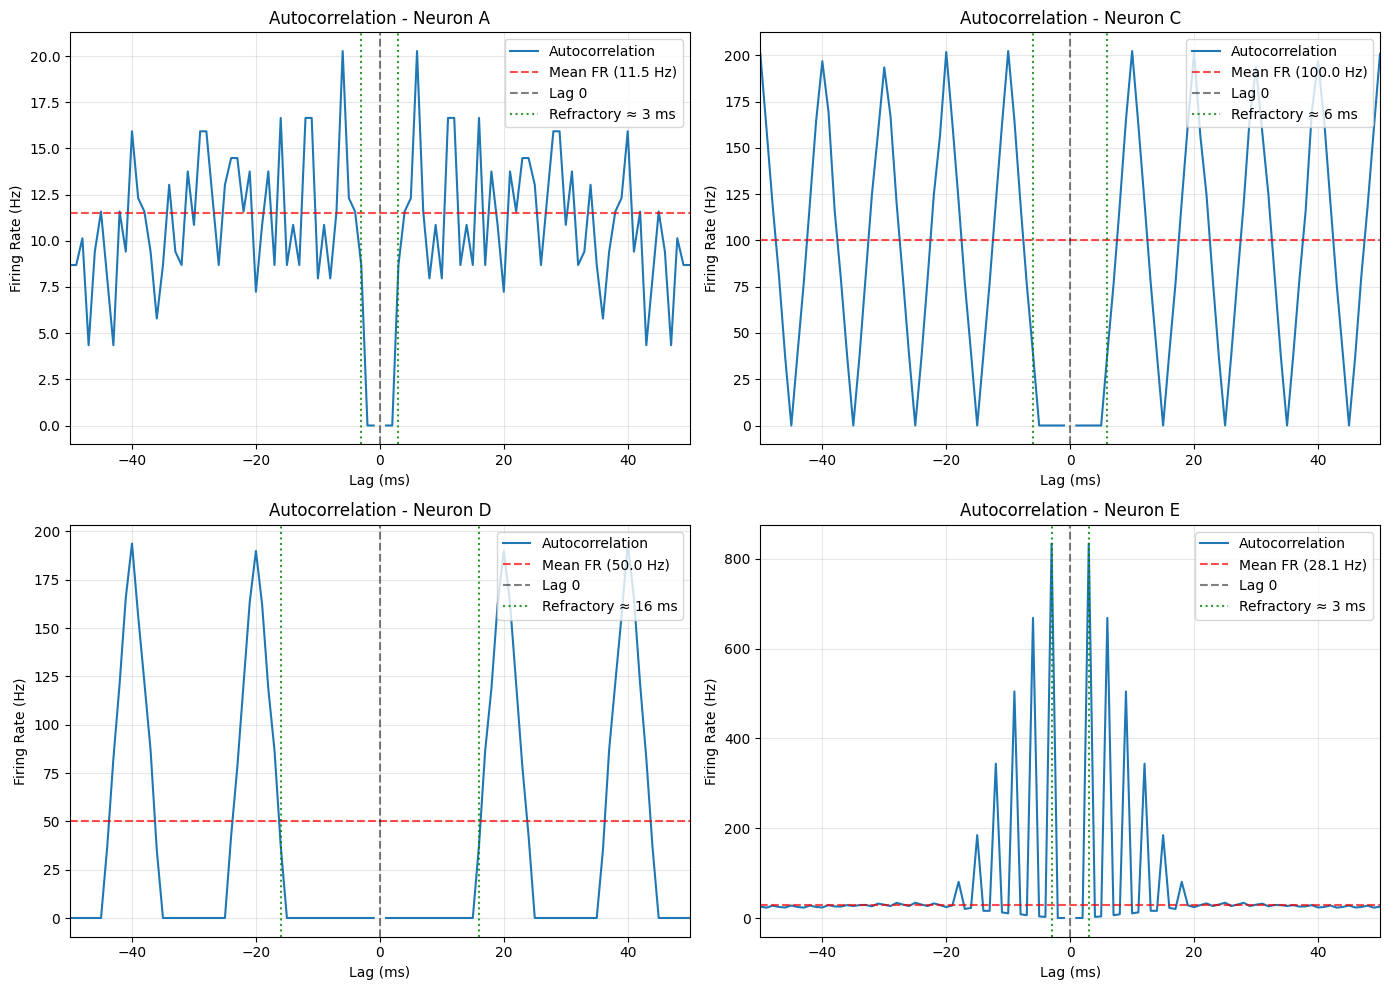

In [ ]:
##### 3.2A - Autocorrelation for Neurons A, C, D and E (first 2 minutes) #####

# Define the recording duration to analyze
recording_duration_sec = 120   # 2 minutes
recording_duration_bins = int(recording_duration_sec * fs_spikes) # s to bins

# Define zoom window around lag 0
zoom_lag_ms = 50  # lags from -50 ms to +50 ms

# Neurons required in the question
neurons_to_plot = ['A', 'C', 'D', 'E']

print(f"--- Part 3.2A: Autocorrelation (0-{recording_duration_sec}s) ---\n")

plt.figure(figsize=(14, 10))

for i, neuron in enumerate(neurons_to_plot):

    # Flatten all trials into one long recording and take only the first 2 minutes
    data_2min = neuron_data_dict[neuron].flatten()[:recording_duration_bins]

    # Count total spikes and calculate mean firing rate
    total_spikes = np.sum(data_2min)
    mean_firing_rate = total_spikes / recording_duration_sec

    # Calculate AC
    # Equivalent to np.correlate(x, x, mode='full'),but faster for long signals
    autocorr_counts = correlate(data_2min, data_2min, mode='full', method='fft')

    # Create lag axis and convert it from bins to milliseconds
    lags_bins = np.arange(-len(data_2min) + 1, len(data_2min))
    lags_ms = (lags_bins / fs_spikes) * 1000

    # Normalize autocorrelation to firing rate in Hz
    autocorr_hz = (autocorr_counts / total_spikes) * fs_spikes

    # Remove lag 0 from the plotted signal
    # Lag 0 is each spike correlated with itself, so it is not informative
    autocorr_hz[lags_bins == 0] = np.nan

    # Estimate refractory period:
    # first positive lag after 0 where autocorrelation becomes non-zero again
    pos_mask = (lags_ms > 0) & (lags_ms <= zoom_lag_ms)
    pos_lags = lags_ms[pos_mask]
    pos_counts = autocorr_counts[pos_mask]

    nonzero_indices = np.where(pos_counts > 0)[0]
    refractory_estimate = pos_lags[nonzero_indices[0]]

    # Print useful values - Split into two lines for better screenshotting
    print(f"Neuron {neuron}: Mean FR = {mean_firing_rate:.2f} Hz |"
          f"Refractory ≈ {refractory_estimate:.1f} ms\n")

    # Select only the zoomed range around lag 0
    zoom_mask = (lags_ms >= -zoom_lag_ms) & (lags_ms <= zoom_lag_ms)

    # Plot
    plt.subplot(2, 2, i + 1)
    plt.plot(lags_ms[zoom_mask], autocorr_hz[zoom_mask], label='Autocorrelation')

    # Add horizontal line for mean firing rate
    plt.axhline(
        mean_firing_rate,
        color='red',
        linestyle='--',
        alpha=0.7,
        label=f'Mean FR ({mean_firing_rate:.1f} Hz)'
    )

    # Add vertical lines for lag 0 and refractory period
    plt.axvline(0, color='black', linestyle='--', alpha=0.5, label='Lag 0')
    plt.axvline(refractory_estimate, color='green', linestyle=':', alpha=0.8,
                label=f'Refractory ≈ {refractory_estimate:.0f} ms')
    plt.axvline(-refractory_estimate, color='green', linestyle=':', alpha=0.8)

    plt.title(f'Autocorrelation - Neuron {neuron}')
    plt.xlabel('Lag (ms)')
    plt.ylabel('Firing Rate (Hz)')
    plt.xlim(-zoom_lag_ms, zoom_lag_ms)
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### B - Which type of neuron C is? Explain in relation to the autocorrelation function. Does the FF value match your hypothesis? Explain

Neuron C is oscillatory (regular). As can be seen in the autocorrelation graph, the function displays recurring peaks at regular time intervals, which indicates very rhythmic, periodic, and regular activity. This firing pattern is consistent with the FF value I calculated for this neuron (in section 3.1B, FF = 0.000). An FF value of zero means that the variance of the firing rate across trials is negligible, that is, the neuron fires exactly the same number of spikes in any given time window, without any deviation (at least, according to the data). This is the hallmark of a regular oscillatory neuron, in contrast to random (Poisson) firing where the expected value equals the variance and the FF approaches 1.

### C - Which type of neuron D is? Explain the differences between the autocorrelation functions of C and D

Neuron D is also oscillatory (regular). Based on the autocorrelation graph, similar to Neuron C, it maintains clear periodicity even for large lag values, manifested by recurring peaks at regular time intervals. This pattern indicates rhythmic, regular activity and a strong temporal dependence between spike times. The main difference between the two neurons is evident in the distance (time interval) between the peaks, which reflects the neuron's period. In Neuron C, the peaks are much denser, indicating a short period and a fast rhythmic firing rate (approx. 100Hz). In contrast, in Neuron D's autocorrelation function, the peaks are significantly more spaced out, indicating a longer period and a slower rhythmic firing rate (approx. 50Hz). This is also reflected in the differences in the FF values of the neurons: 0.0102 > 0.0000.

### D - Explain the shape around lag 0 of the autocorrelation

In Neuron E's autocorrelation graph, high and dense peaks concentrated around Lag 0 can be observed. This shape indicates that after each spike, there is a very high probability of additional spikes appearing immediately afterward (i.e., in clusters/groups). A neuron with a firing pattern that fires in bursts and then remains silent, and accordingly with an FF value significantly greater than 1 (FF ≈ 6.65), is characteristic of a Bursting neuron. The number of peaks densely concentrated around zero tells us about the average number of spikes that make up one burst in this specific neuron. In the graph, about 6 consecutive peaks can be seen after Lag 0, so it can be inferred that a typical burst of Neuron E includes about 7 spikes (the original spike plus approximately 6 consecutive spikes). After each peak, a local minimum appears, meaning a temporary decrease in the probability of another spike immediately after that spike. This indicates that the spikes within the burst do not appear in a completely random sequence but are separated by relatively short time intervals. This minimum represents a short refractory period of approximately 3ms according to the graph (a small, constant interval between spikes within the burst). This interval shows that even during an intense and rapid burst firing, the neuron still requires a short and essential recovery time between spikes.

### E - Compute the Cross-Correlation of the first 2 minutes of Neuron A and Neuron B, without normalizing.

--- Part 3.2E: Cross-Correlation A-B (0-120s) ---

Peak lag = 2.0 ms
Peak value = 1297 raw counts



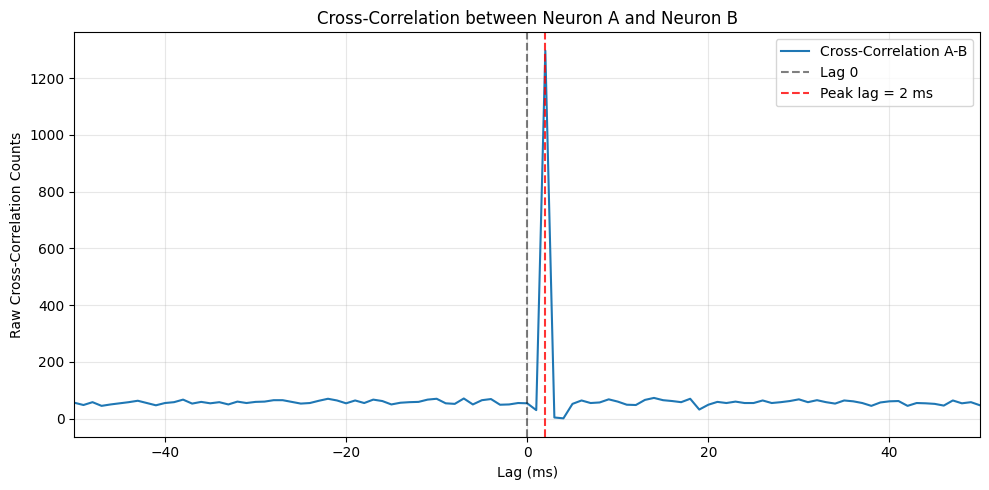

In [ ]:
##### 3.2E - Cross-Correlation between Neuron A and Neuron B (first 2 minutes) #####

# Define the recording duration to analyze
recording_duration_sec = 120   # 2 minutes
recording_duration_bins = int(recording_duration_sec * fs_spikes)

# Define zoom window around lag 0
zoom_lag_ms = 50

print(f"--- Part 3.2E: Cross-Correlation A-B (0-{recording_duration_sec}s) ---\n")

# Flatten all trials into one long recording and take only the first 2 minutes
A_2min = neuron_data_dict['A'].flatten()[:recording_duration_bins]
B_2min = neuron_data_dict['B'].flatten()[:recording_duration_bins]

# Calculate cross-correlation without normalization
# We compute B relative to A:
# If A tends to trigger B after a delay, we expect a peak at a positive lag
cc_counts = correlate(B_2min, A_2min, mode='full', method='fft')

# Create lag axis and convert it from bins to milliseconds
lags_bins = np.arange(-len(A_2min) + 1, len(A_2min))
lags_ms = (lags_bins / fs_spikes) * 1000

# Select only the zoomed range around lag 0
zoom_mask = (lags_ms >= -zoom_lag_ms) & (lags_ms <= zoom_lag_ms)

# Find the peak in the zoomed cross-correlation
peak_idx = np.argmax(cc_counts[zoom_mask])
peak_lag = lags_ms[zoom_mask][peak_idx]
peak_value = cc_counts[zoom_mask][peak_idx]

print(f"Peak lag = {peak_lag:.1f} ms")
print(f"Peak value = {peak_value:.0f} raw counts\n")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(lags_ms[zoom_mask], cc_counts[zoom_mask], label='Cross-Correlation A-B')

# Add vertical line at lag 0
plt.axvline(0, color='black', linestyle='--', alpha=0.5, label='Lag 0')

# Add vertical line at the peak
plt.axvline(peak_lag, color='red', linestyle='--', alpha=0.8,
            label=f'Peak lag = {peak_lag:.0f} ms')

plt.title('Cross-Correlation between Neuron A and Neuron B')
plt.xlabel('Lag (ms)')
plt.ylabel('Raw Cross-Correlation Counts')
plt.xlim(-zoom_lag_ms, zoom_lag_ms)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### G -	Compute and plot the Cross-Correlation of the first 2 minutes of Neuron C and Neuron D.
 Explain the plot.

--- Part 3.2G: Cross-Correlation C-D (0-120s), Normalized ---

Neuron C Mean FR = 100.00 Hz
Neuron D Mean FR = 49.99 Hz



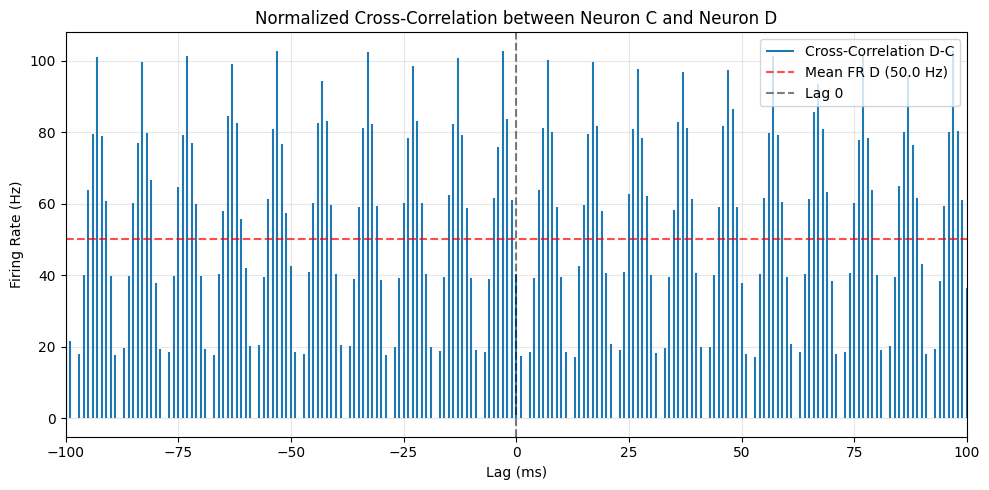

In [ ]:
##### 3.2G - Normalized Cross-Correlation between Neuron C and Neuron D (first 2 minutes) #####


# Define the recording duration to analyze
recording_duration_sec = 120   # 2 minutes
recording_duration_bins = int(recording_duration_sec * fs_spikes)

# Define zoom window around lag 0
zoom_lag_ms = 100

print(f"--- Part 3.2G: Cross-Correlation C-D (0-{recording_duration_sec}s), Normalized ---\n")

# Flatten all trials into one long recording and take only the first 2 minutes
C_2min = neuron_data_dict['C'].flatten()[:recording_duration_bins]
D_2min = neuron_data_dict['D'].flatten()[:recording_duration_bins]

# Count total spikes of the reference neuron C
total_spikes_C = np.sum(C_2min)

# Calculate mean firing rates
mean_fr_C = np.sum(C_2min) / recording_duration_sec
mean_fr_D = np.sum(D_2min) / recording_duration_sec

# Calculate cross-correlation
# We compute D relative to C
cc_counts = correlate(D_2min, C_2min, mode='full', method='fft')

# Create lag axis and convert it from bins to milliseconds
lags_bins = np.arange(-len(C_2min) + 1, len(C_2min))
lags_ms = (lags_bins / fs_spikes) * 1000

# Normalize the cross-correlation to firing rate in Hz
# Divide by the number of spikes in C, then multiply by fs_spikes
cc_hz = (cc_counts / total_spikes_C) * fs_spikes

# Select only the zoomed range around lag 0
zoom_mask = (lags_ms >= -zoom_lag_ms) & (lags_ms <= zoom_lag_ms)

# Print useful values
print(f"Neuron C Mean FR = {mean_fr_C:.2f} Hz")
print(f"Neuron D Mean FR = {mean_fr_D:.2f} Hz\n")

# Plot
plt.figure(figsize=(10, 5))
plt.vlines(
    lags_ms[zoom_mask],
    0,
    cc_hz[zoom_mask],
    label='Cross-Correlation D-C'
)

# Add horizontal line for mean firing rate of neuron D
plt.axhline(
    mean_fr_D,
    color='red',
    linestyle='--',
    alpha=0.7,
    label=f'Mean FR D ({mean_fr_D:.1f} Hz)'
)

# Add vertical line at lag 0
plt.axvline(0, color='black', linestyle='--', alpha=0.5, label='Lag 0')

plt.title('Normalized Cross-Correlation between Neuron C and Neuron D')
plt.xlabel('Lag (ms)')
plt.ylabel('Firing Rate (Hz)')
plt.xlim(-zoom_lag_ms, zoom_lag_ms)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()